# Portfolio Optimization With Constraints in Python

*Quant Lab · The Analytical Investor · Year 1, Month 8*

**Read the article:** [Portfolio Optimization With Constraints in Python](https://analytical-investor.blog/?p=1019)

Unconstrained, long-only and 'house rules' portfolios for the same 8% target, then a stress test showing why constraints make portfolios robust to estimation error.

> Run locally with `pip install -e ".[notebooks]"` from the repo root, then open this notebook in Jupyter. All data is simulated with fixed seeds, so every number matches the article.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9, 5), "axes.grid": True, "grid.alpha": 0.3})

## Step 1
Set up the five-asset universe and solve the three regimes.

In [2]:
import numpy as np
from scipy.optimize import minimize

# ------------------------------------------------------------------
# 1. Universe assumptions (annual, illustrative planning inputs)
# ------------------------------------------------------------------
assets = ["Local Eq", "Global Eq", "Gov Bonds", "Real Estate", "Cash"]
mu  = np.array([0.12, 0.09, 0.06, 0.08, 0.04])
vol = np.array([0.25, 0.16, 0.07, 0.14, 0.01])

corr = np.array([
    [1.00, 0.55, 0.10, 0.45, 0.00],
    [0.55, 1.00, 0.05, 0.35, 0.00],
    [0.10, 0.05, 1.00, 0.10, 0.05],
    [0.45, 0.35, 0.10, 1.00, 0.00],
    [0.00, 0.00, 0.05, 0.00, 1.00],
])
cov = np.outer(vol, vol) * corr
n = len(assets)

# ------------------------------------------------------------------
# 2. Generic constrained optimizer: minimize variance for target return
# ------------------------------------------------------------------
def solve(target_ret, bounds, extra_cons=()):
    cons = [
        {"type": "eq",   "fun": lambda w: w.sum() - 1},
        {"type": "ineq", "fun": lambda w: w @ mu - target_ret},
        *extra_cons,
    ]
    res = minimize(lambda w: w @ cov @ w,
                   x0=np.full(n, 1/n),
                   method="SLSQP", bounds=bounds, constraints=cons)
    return res.x if res.success else None

# ------------------------------------------------------------------
# 3. Three regimes: unconstrained, long-only, house rules
# ------------------------------------------------------------------
target = 0.08

w_unc = solve(target, bounds=[(-1, 2)] * n)          # shorting allowed

w_lo  = solve(target, bounds=[(0, 1)] * n)           # long-only

house = [  # long-only, 30% single-asset cap, defensives >= 20%
    {"type": "ineq", "fun": lambda w: w[2] + w[4] - 0.20},
]
w_hr  = solve(target, bounds=[(0, 0.30)] * n, extra_cons=house)

def report(label, w):
    if w is None:
        print(f"{label}: infeasible"); return
    r, v = w @ mu, np.sqrt(w @ cov @ w)
    alloc = ", ".join(f"{a} {x:.0%}" for a, x in zip(assets, w))
    print(f"{label}\n  {alloc}\n  ret {r:.2%}  vol {v:.2%}  Sharpe {(r-0.04)/v:.2f}\n")

report("Unconstrained", w_unc)
report("Long-only",     w_lo)
report("House rules",   w_hr)

Unconstrained
  Local Eq 10%, Global Eq 21%, Gov Bonds 68%, Real Estate 19%, Cash -19%
  ret 8.00%  vol 8.74%  Sharpe 0.46

Long-only
  Local Eq 17%, Global Eq 21%, Gov Bonds 45%, Real Estate 17%, Cash 0%
  ret 8.00%  vol 9.01%  Sharpe 0.44

House rules
  Local Eq 14%, Global Eq 26%, Gov Bonds 30%, Real Estate 25%, Cash 5%
  ret 8.00%  vol 9.29%  Sharpe 0.43



## Step 2
Perturb expected returns and measure how much each portfolio's outcome moves.

In [3]:
# ------------------------------------------------------------------
# 4. Estimation-error stress test: perturb inputs, re-measure
# ------------------------------------------------------------------
rng = np.random.default_rng(3)
def realized(w, trials=2_000):
    outcomes = []
    for _ in range(trials):
        mu_true = mu + rng.normal(0, 0.02, n)        # 2% return uncertainty
        outcomes.append(w @ mu_true - 0.5 * (w @ cov @ w))
    return np.mean(outcomes), np.std(outcomes)

for label, w in [("Unconstrained", w_unc), ("Long-only", w_lo),
                 ("House rules", w_hr)]:
    if w is not None:
        m, s = realized(w)
        print(f"{label}: mean utility {m:.4f}, dispersion {s:.4f}")

Unconstrained: mean utility 0.0766, dispersion 0.0155
Long-only: mean utility 0.0762, dispersion 0.0107
House rules: mean utility 0.0758, dispersion 0.0098


### Three portfolios, one target
The unconstrained solution borrows (negative cash) to shave volatility; the constrained ones stay explicable.

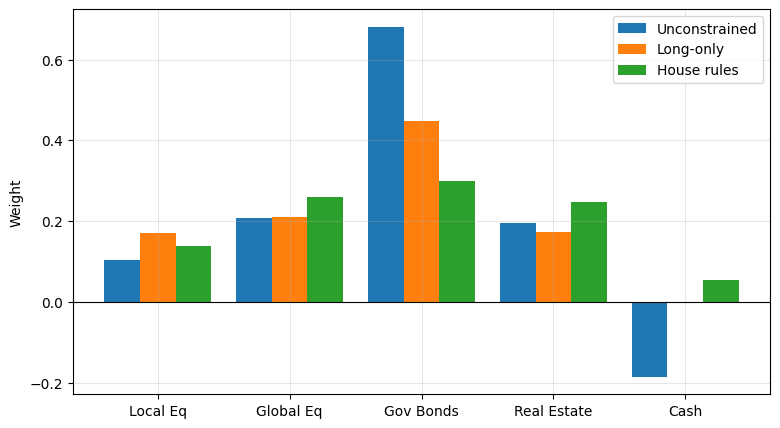

In [4]:
W = np.vstack([w_unc, w_lo, w_hr])
x = np.arange(len(assets)); width = 0.27
for i, lab in enumerate(["Unconstrained", "Long-only", "House rules"]):
    plt.bar(x + (i - 1) * width, W[i], width, label=lab)
plt.axhline(0, color="k", lw=0.8)
plt.xticks(x, assets); plt.ylabel("Weight"); plt.legend(); plt.show()

## The same thing with the toolkit
The model above lives in the `analytical_investor` package, tested and reusable.

In [5]:
from analytical_investor import portfolio as P

w = P.target_return_portfolio(mu, cov, 0.08, bounds=[(0, 0.30)] * n, extra_constraints=house)
print(dict(zip(assets, w.round(3))))

{'Local Eq': np.float64(0.139), 'Global Eq': np.float64(0.26), 'Gov Bonds': np.float64(0.3), 'Real Estate': np.float64(0.247), 'Cash': np.float64(0.054)}


---
The article's **Limitations** section explains what this model leaves out. [Read it here](https://analytical-investor.blog/?p=1019).